In [283]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix

In [284]:
current_file = Path.cwd()
ROOT = current_file.parent.parent

data = pd.read_csv(f"{ROOT}/data/hipertension_arterial_ mexico_dataset/Hipertension_Arterial_Mexico.csv")

In [285]:
data.head()

,FOLIO_I,sexo,edad,concentracion_hemoglobina,temperatura_ambiente,valor_acido_urico,valor_albumina,valor_colesterol_hdl,valor_colesterol_ldl,valor_colesterol_total,...,segundamedicion_peso,segundamedicion_estatura,distancia_rodilla_talon,circunferencia_de_la_pantorrilla,segundamedicion_cintura,tension_arterial,sueno_horas,masa_corporal,actividad_total,riesgo_hipertension
0,2022_01001004,2,41,14.2,22,4.8,4.0,34,86.0,139,...,64.70,154.0,48.5,33.5,0.0,107,4,32.889389,120,1
1,2022_01001009,2,65,14.1,9,4.4,3.8,73,130.0,252,...,96.75,152.2,44.5,41.1,113.7,104,2,1.000000,240,0
2,2022_01001012,2,68,14.2,22,4.8,4.0,34,86.0,139,...,68.70,144.8,42.3,37.8,103.7,105,1,1.000000,480,0
3,2022_01001013,1,35,15.7,11,6.5,4.1,49,107.0,203,...,64.70,154.0,48.5,33.5,0.0,117,5,26.265339,275,1
4,2022_01001015,2,65,12.7,7,4.2,4.2,41,76.0,145,...,97.15,161.3,49.6,42.0,118.9,123,2,1.000000,255,0


In [286]:
train_data, test_data = train_test_split(data, test_size=0.25, random_state=42, stratify=data["riesgo_hipertension"])

train_data: pd.DataFrame
test_data: pd.DataFrame

y_train = train_data["riesgo_hipertension"]
x_train = train_data.drop(columns=["FOLIO_I", "valor_colesterol_total", "riesgo_hipertension"])
y_test = test_data["riesgo_hipertension"]
x_test = test_data.drop(columns=["FOLIO_I", "valor_colesterol_total", "riesgo_hipertension"])

In [287]:
train_data["riesgo_hipertension"].value_counts(normalize=True)

riesgo_hipertension
1    0.645477
0    0.354523
Name: proportion, dtype: float64

In [288]:
x_train.info()

<class 'pandas.DataFrame'>
Index: 3272 entries, 191 to 2735
Data columns (total 33 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   sexo                              3272 non-null   int64  
 1   edad                              3272 non-null   int64  
 2   concentracion_hemoglobina         3272 non-null   float64
 3   temperatura_ambiente              3272 non-null   int64  
 4   valor_acido_urico                 3272 non-null   float64
 5   valor_albumina                    3272 non-null   float64
 6   valor_colesterol_hdl              3272 non-null   int64  
 7   valor_colesterol_ldl              3272 non-null   float64
 8   valor_creatina                    3272 non-null   float64
 9   resultado_glucosa                 3272 non-null   float64
 10  valor_insulina                    3272 non-null   float64
 11  valor_trigliceridos               3272 non-null   int64  
 12  resultado_glucosa_pr

In [289]:
x_train["sexo"] = x_train["sexo"].astype("category")
x_test["sexo"] = x_test["sexo"].astype("category")

x_train.info()

<class 'pandas.DataFrame'>
Index: 3272 entries, 191 to 2735
Data columns (total 33 columns):
 #   Column                            Non-Null Count  Dtype   
---  ------                            --------------  -----   
 0   sexo                              3272 non-null   category
 1   edad                              3272 non-null   int64   
 2   concentracion_hemoglobina         3272 non-null   float64 
 3   temperatura_ambiente              3272 non-null   int64   
 4   valor_acido_urico                 3272 non-null   float64 
 5   valor_albumina                    3272 non-null   float64 
 6   valor_colesterol_hdl              3272 non-null   int64   
 7   valor_colesterol_ldl              3272 non-null   float64 
 8   valor_creatina                    3272 non-null   float64 
 9   resultado_glucosa                 3272 non-null   float64 
 10  valor_insulina                    3272 non-null   float64 
 11  valor_trigliceridos               3272 non-null   int64   
 12  result

In [290]:
numerical_columns = x_train.select_dtypes(["float64","Int64"]).columns.to_list()
categorical_columns = x_train.select_dtypes(["category"]).columns.to_list()

In [291]:
encoder = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_columns),
        ("cat", OneHotEncoder(drop="first", sparse_output=False), categorical_columns)
    ]
)

encoder.set_output(transform="pandas")

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

In [292]:
x_train_encoded = encoder.fit_transform(x_train)

In [293]:
model = GaussianNB(priors=[0.5,0.5]).fit(x_train_encoded, y_train)

In [294]:
y_pred = model.predict(x_train_encoded)

In [295]:
print(classification_report(y_train, y_pred))

              precision    recall  f1-score   support

           0       0.77      0.59      0.67      1160
           1       0.80      0.90      0.85      2112

    accuracy                           0.79      3272
   macro avg       0.78      0.75      0.76      3272
weighted avg       0.79      0.79      0.78      3272



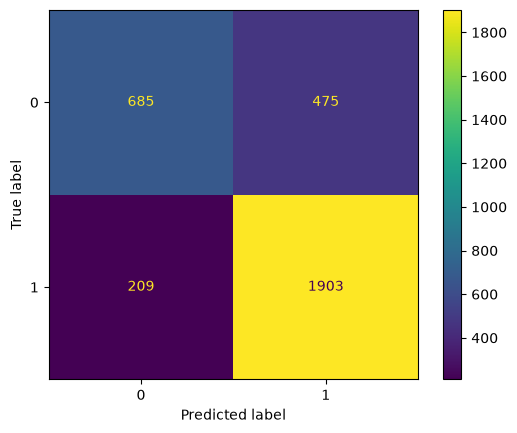

In [296]:
ConfusionMatrixDisplay.from_predictions(y_train, y_pred)
plt.show()